## Housing Price Analysis

Here we will analyzing differenct factors that might effect the sale price of a Home. From these insights we will be able to recommend mortgatage loans we should invest in. 

In [1]:
# importing the libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
%matplotlib inline

In [2]:
df = pd.read_csv('housing-price-data-04042019.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


There are 19 coulmns out of 81 with missing values in the data set
Percentage of misisng values from columns
 PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


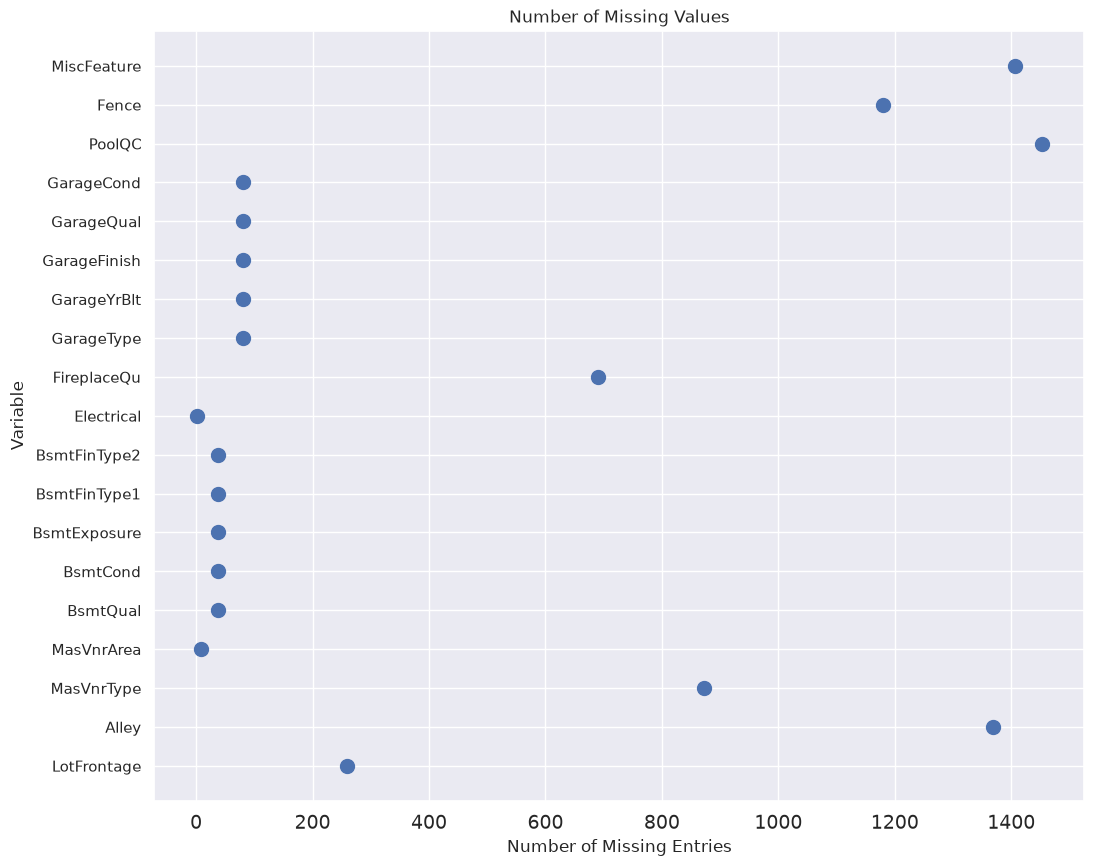

In [3]:
# cleaning the data and saving to csv file 
# finding missing data

cols_missing = df.columns[df.isnull().any()].values
print('There are {} coulmns out of {} with missing values in the data set'.format(cols_missing.shape[0], df.shape[1]))

# we can visualize the missing data and also calculate percentages to impute best way to impute or omit the missing data
num_missing_values = len(df) - df.loc[:, df.isnull().sum()>0].count()
percent_missing = ((num_missing_values/df.shape[0])*100).sort_values(ascending=False)
print('Percentage of misisng values from columns\n',percent_missing)


x = num_missing_values.index
y = num_missing_values 

fig, ax = plt.subplots(figsize=(12,10))
plt.xticks(fontsize=14)
ax.scatter(y,x, s=100)
ax.set_title('Number of Missing Values')
ax.set_ylabel('Variable')
ax.set_xlabel('Number of Missing Entries')
fig.savefig('images/Missing Values.png')

# x = percent_missing.index
# y = percent_missing

# fig, ax2 = plt.subplots(figsize=(14,16))
# plt.xticks(fontsize=14)
# ax2.scatter(y,x, s=100, color='green')
# ax2.set_title('Number of Missing Values')
# ax2.set_ylabel('Variable')
# ax2.set_xlabel('Number of Missing Entries')

### Imputing for missing values 

When looking at missing values we usually drop cols with large ammounts 
of missing data, however from data description we can treat many columns 
as 0 or none instead of NaN.

For categorical columns we will impute the mode, and for discrete or contiunous numerical values we will impute by thier means.


In [4]:
''' looking at missing values we usually drop cols with large ammounts 
of missing data, however from data description we can treat many columns 
as 0 or none instead of NaN. '''

none_cols = df[['PoolQC','MiscFeature','Alley', 'Fence', 'FireplaceQu', 
                    'GarageType', 'GarageCond','GarageFinish','GarageQual',
                    'BsmtFinType2','BsmtExposure','BsmtQual','BsmtCond','BsmtFinType1','MasVnrType']]

mode_cols = df[['Electrical', 'MSZoning','Utilities','Exterior1st',
                    'Exterior2nd','KitchenQual','Functional', 'SaleType']]

median_cols = df[['BsmtFullBath','LotFrontage', 'BsmtHalfBath', 'GarageCars', 'MasVnrArea',
                      'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea']]


# looping through each column and imputing missing values for each type 
for i in none_cols.columns:
    df[i].fillna('None', inplace=True)  # filling in None for missing 
    
for i in mode_cols.columns:
    df[i].fillna(df[i].mode()[0], inplace=True)
    
for i in median_cols.columns:
    df[i].fillna(df[i].median(), inplace=True)
    
cols_missing = df.columns[df.isnull().any()].values
print('There are {} coulmns out of {} with missing values in the data set'.format(cols_missing.shape[0], df.shape[1]))



There are 19 coulmns out of 81 with missing values in the data set


/tmp/ipykernel_15334/2594438379.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[i].fillna('None', inplace=True)  # filling in None for missing
/tmp/ipykernel_15334/2594438379.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace 

### Visualzations and EDA

To see if there is any correlation witht he variables and sales price we can  begin by first looking at a correlation heat map to see what corelates most to salesPrice and then do further investigation on those variables.

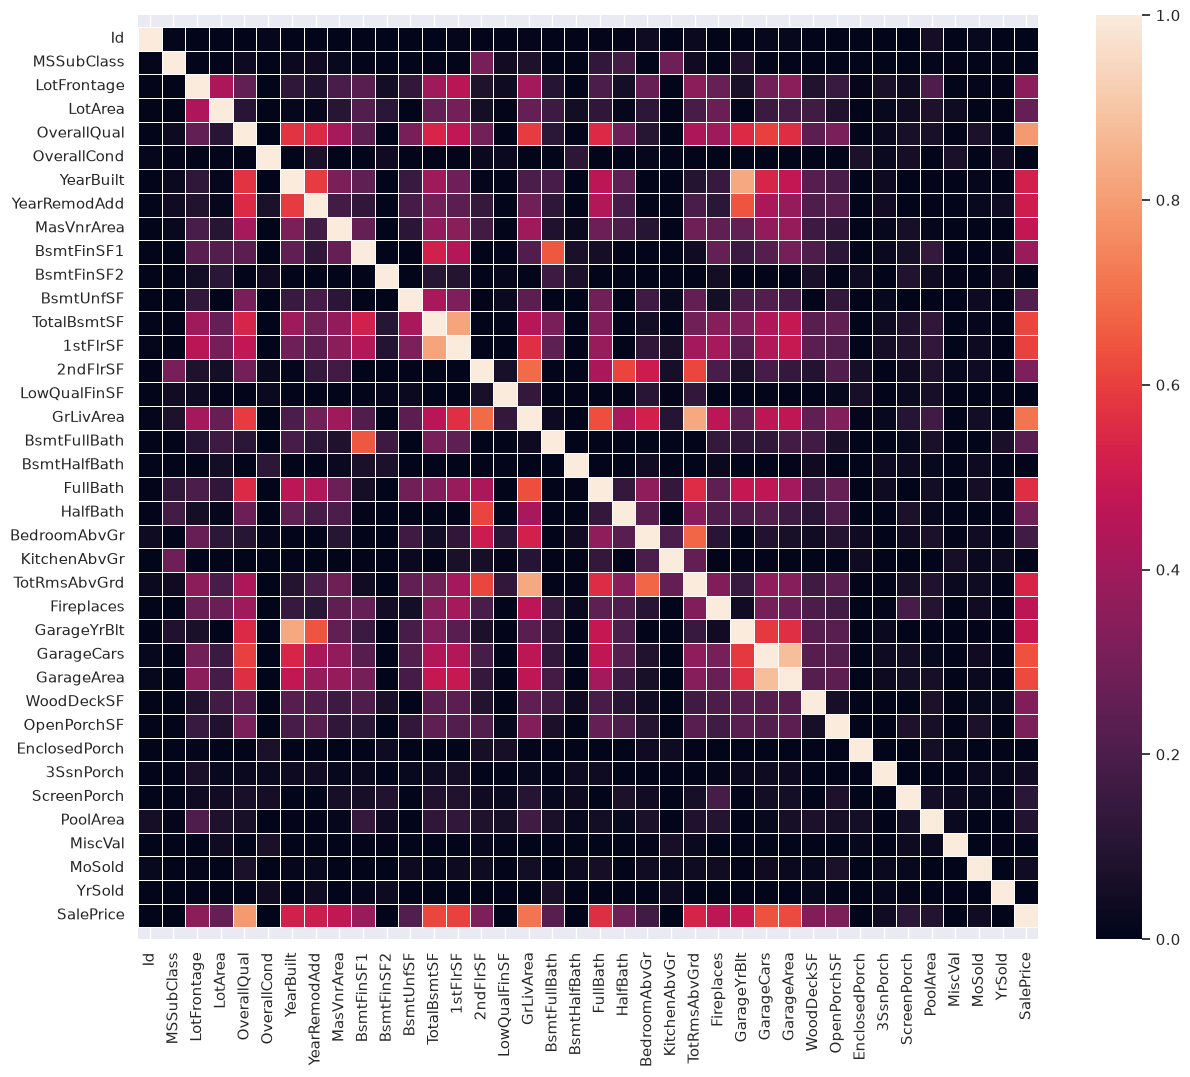

In [5]:
corr = df.corr(numeric_only=True)  # numeric cols only (pandas>=2 raises on strings)
fig, ax = plt.subplots(figsize=(15,12))
sns.heatmap(corr, linewidths=.5, vmin=0, vmax=1, square=True)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
# ax.set_xlabel(corr.index, fontsize =10)
fig.savefig('images/Correlation.png')


In [6]:
corr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


From the above heat map we can see that SalesPrices seems to most correlate with variables like OverallQual, TotalBsmntSF, 1stFlrSF, GrLivArea, FulllBath, TotRmsAbvGr, GarageCars, GarageArea. Alot of these variables are obviously intercorrelated. 

"\n\n## note this join is not correct have to join category with numerical based off id before contiuning\n\n\n# joining categorical columns of interest to colums variable\ndf2 = cols.concat(df.select_dtypes(includes='object'))"

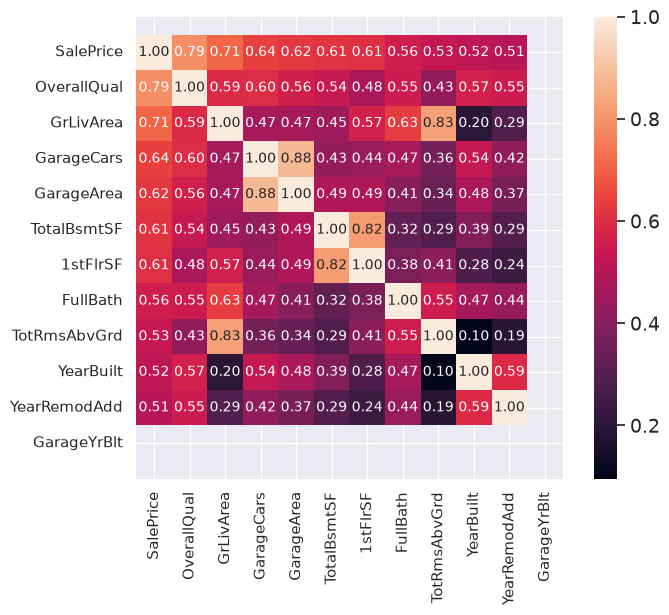

In [7]:
## we can make a more consise corr matrix based on sales price

k = 12 #number of variables for heatmap
cols = corr.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df[cols].values.T)
fig, ax = plt.subplots(figsize=(8,6))
sns.set(font_scale=1.25)
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values, ax=ax)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

plt.savefig('images/smaller_corr.png')
'''

## note this join is not correct have to join category with numerical based off id before contiuning


# joining categorical columns of interest to colums variable
df2 = cols.concat(df.select_dtypes(includes='object'))'''

In [8]:
cols.values
dfs = []
for i in cols.values:
   dfs.append(df[i])
decade_built = (df[['YearBuilt']]//10 * 10).rename(columns={'YearBuilt':'DecadeBuilt'}) 
print(decade_built.head())
correlated_df = pd.concat(dfs, axis =1)
correlated_df = pd.concat([correlated_df, decade_built, df[['Id']]], axis=1).set_index('Id')
correlated_df.to_csv('clean_data.csv', index=False)  # saving the clean data to new csv file. 
correlated_df.head()

   DecadeBuilt
0         2000
1         1970
2         2000
3         1910
4         2000


,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,DecadeBuilt
Id,,,,,,,,,,,,,
1,208500,7,1710,2,548,856,856,2,8,2003,2003,2003.0,2000
2,181500,6,1262,2,460,1262,1262,2,6,1976,1976,1976.0,1970
3,223500,7,1786,2,608,920,920,2,6,2001,2002,2001.0,2000
4,140000,7,1717,3,642,756,961,1,7,1915,1970,1998.0,1910
5,250000,8,2198,3,836,1145,1145,2,9,2000,2000,2000.0,2000


In [9]:
correlated_df.shape

(1460, 13)

Text(0.5, 1.0, 'Distribution of Selling Price per Decade Built')

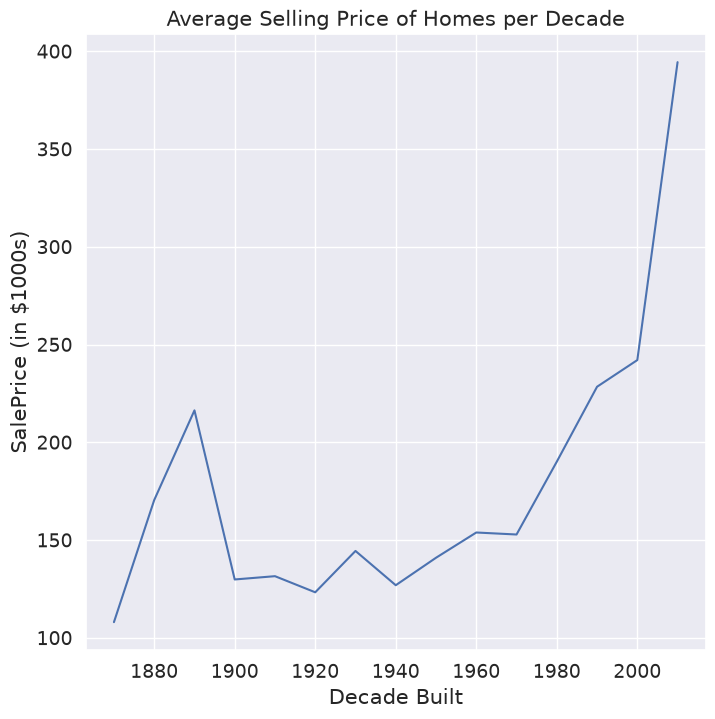

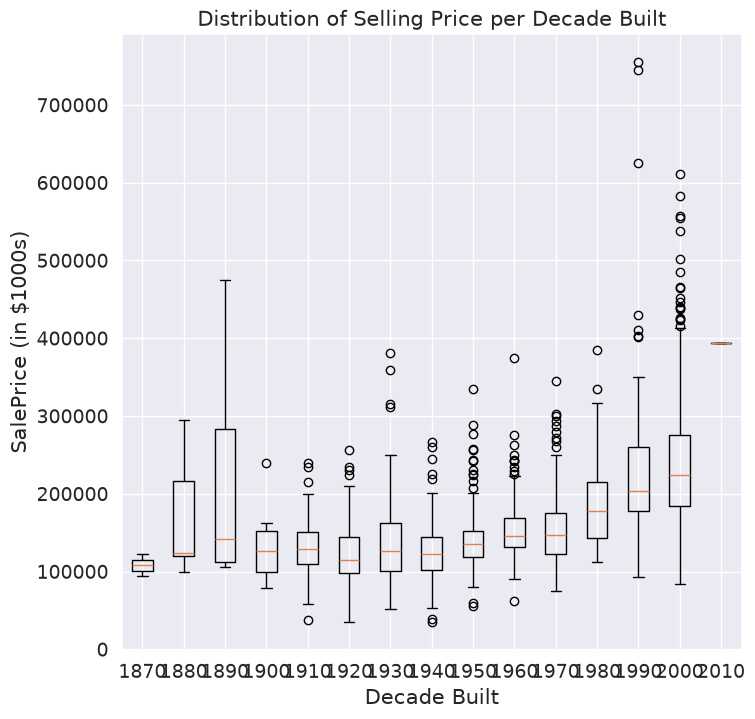

In [10]:
sales_by_decade = correlated_df.groupby('DecadeBuilt')['SalePrice'].mean().reset_index().sort_values(by='DecadeBuilt', ascending=True)
fig, ax =plt.subplots(figsize=(8,8))
plt.plot(sales_by_decade['DecadeBuilt'], sales_by_decade['SalePrice']/1000)
ax.set_xlabel('Decade Built')
ax.set_ylabel('SalePrice (in $1000s)')
ax.set_title('Average Selling Price of Homes per Decade')
fig.savefig('images/AvgHomePrice_decade.png')

fig, ax = plt.subplots(figsize=(8, 8))
decades = sorted(correlated_df['DecadeBuilt'].dropna().unique())
ax.boxplot([correlated_df.loc[correlated_df['DecadeBuilt'] == d, 'SalePrice'].values for d in decades],
           tick_labels=decades)
ax.set_xlabel('Decade Built')
ax.set_ylabel('SalePrice (in $1000s)')
ax.set_title('Distribution of Selling Price per Decade Built')  # boxplot needs grouped data, not (x, y)



From looking at heat map we see the top 10 correlations to Sale Pirce further observation show GarageCars and GarageArea are closesly correlated and logically that makes sense. large number cars more likely to have larger garage area so we can ommit it

Text(0, 0.5, 'Frequency of Price')

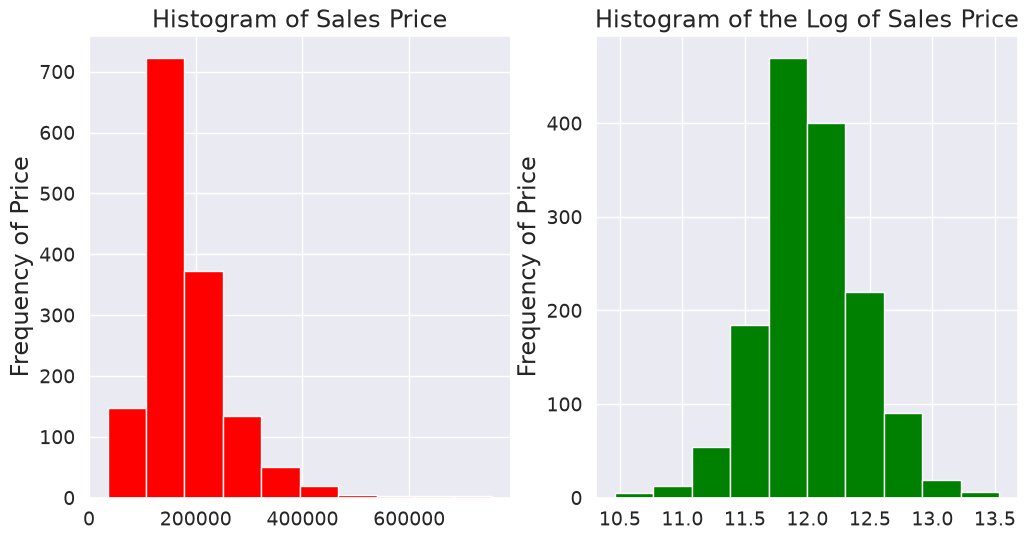

In [11]:
# visulazing the data
fig = plt.figure( figsize = (12,6))
plt.subplot(1,2,1)
plt.hist(df.SalePrice, color='red')
plt.title('Histogram of Sales Price', fontsize = 17)
plt.ylabel('Frequency of Price', fontsize = 17)

# hist of log of Sale Price
plt.subplot(1,2,2)
plt.hist(np.log(df.SalePrice), color='green')
plt.title('Histogram of the Log of Sales Price', fontsize = 17)
plt.ylabel('Frequency of Price', fontsize = 17)

In [12]:
# further observation of data to spot outliers

## From observing data taking the log of sales prics provides more normal distribution
def scatter_plot(x,y, Title, font_size, color):
        
    fig, ax= plt.subplots(figsize=(12,6))
    ax.scatter(x, y, c=color)
    ax.set_title(Title, fontsize = int(font_size))
    

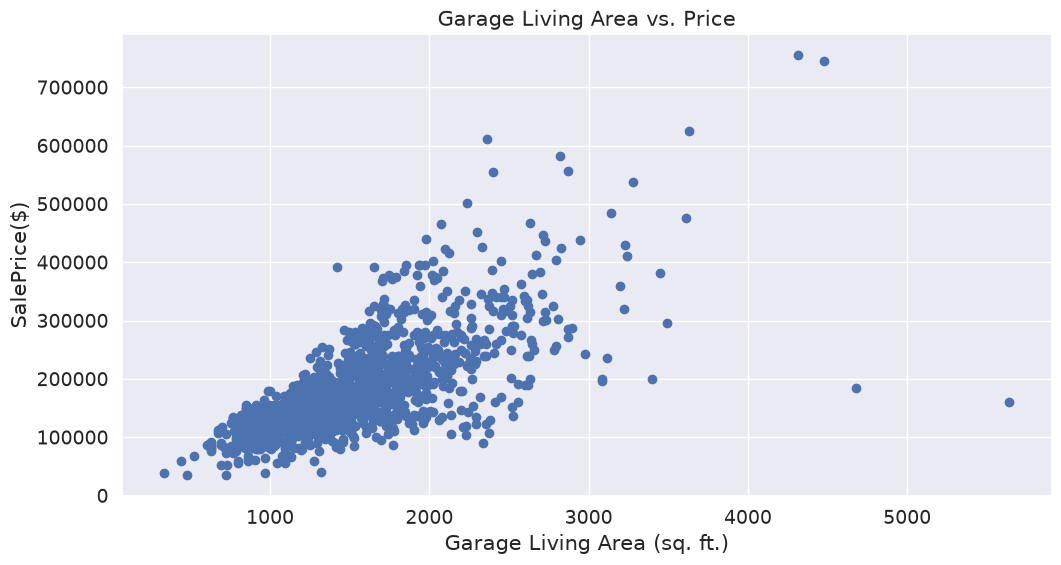

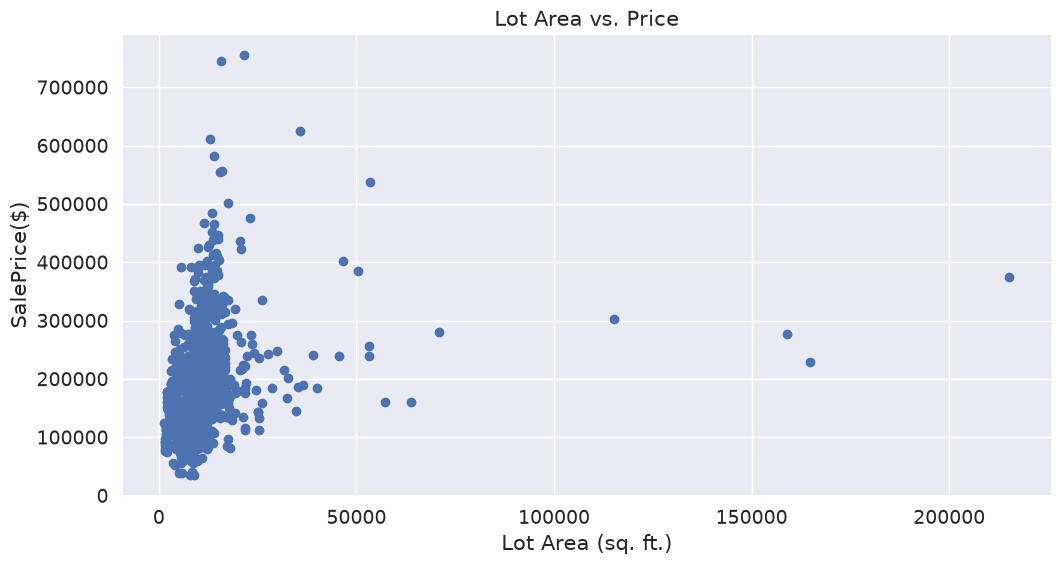

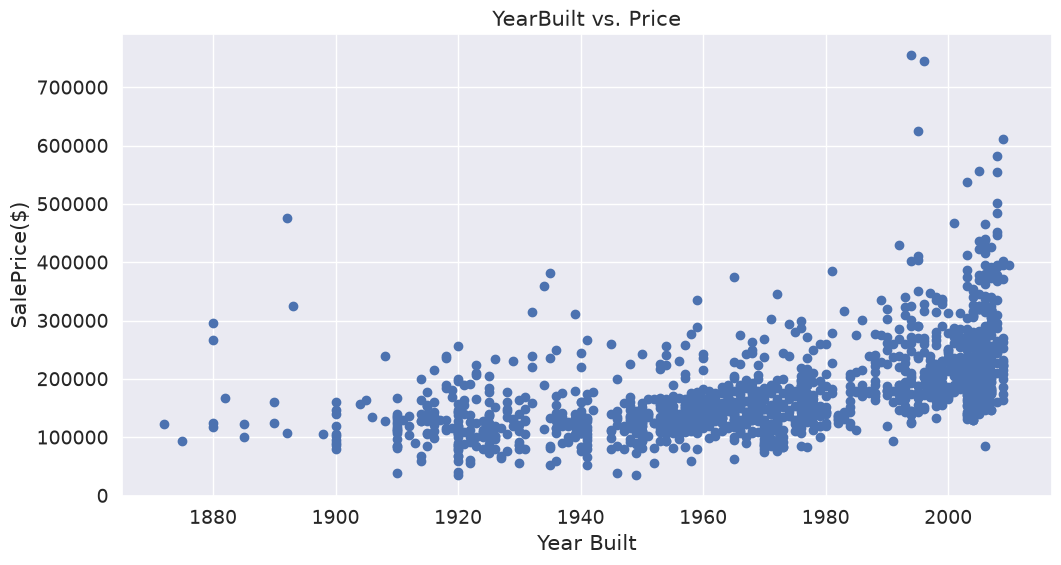

In [13]:
fig, ax= plt.subplots(figsize=(12,6))
ax.scatter(df['GrLivArea'], df['SalePrice'])
ax.set_title('Garage Living Area vs. Price', fontsize = 15)
ax.set_xlabel('Garage Living Area (sq. ft.)')
ax.set_ylabel('SalePrice($)')
fig.savefig('images/LivArea vs. SalePrice.png')


fig, ax= plt.subplots(figsize=(12,6))
ax.scatter(df['LotArea'], df['SalePrice'])
ax.set_title('Lot Area vs. Price', fontsize = 15)
ax.set_xlabel('Lot Area (sq. ft.)')
ax.set_ylabel('SalePrice($)')
fig.savefig('images/LotArea vs. SalePrice.png')

fig, ax= plt.subplots(figsize=(12,6))
ax.scatter(df['YearBuilt'], df['SalePrice'])
ax.set_title('YearBuilt vs. Price', fontsize = 15)
ax.set_xlabel('Year Built')
ax.set_ylabel('SalePrice($)')
fig.savefig('images/YearBuilt vs. SalePrice.png')




<BarContainer object of 1460 artists>

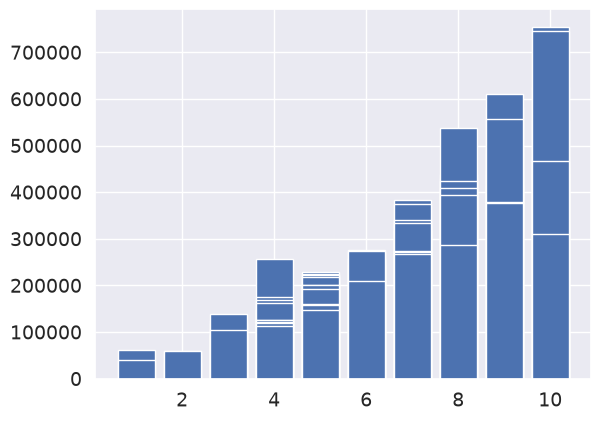

In [14]:
plt.bar(df['OverallQual'], df['SalePrice'])  # fixed: quoted columns, dfp -> df


<StringArray>
[   'MSSubClass',      'MSZoning',   'LotFrontage',       'LotArea',
        'Street',         'Alley',      'LotShape',   'LandContour',
     'Utilities',     'LotConfig',     'LandSlope',  'Neighborhood',
    'Condition1',    'Condition2',      'BldgType',    'HouseStyle',
   'OverallQual',   'OverallCond',     'YearBuilt',  'YearRemodAdd',
     'RoofStyle',      'RoofMatl',   'Exterior1st',   'Exterior2nd',
    'MasVnrType',    'MasVnrArea',     'ExterQual',     'ExterCond',
    'Foundation',      'BsmtQual',      'BsmtCond',  'BsmtExposure',
  'BsmtFinType1',    'BsmtFinSF1',  'BsmtFinType2',    'BsmtFinSF2',
     'BsmtUnfSF',   'TotalBsmtSF',       'Heating',     'HeatingQC',
    'CentralAir',    'Electrical',      '1stFlrSF',      '2ndFlrSF',
  'LowQualFinSF',     'GrLivArea',  'BsmtFullBath',  'BsmtHalfBath',
      'FullBath',      'HalfBath',  'BedroomAbvGr',  'KitchenAbvGr',
   'KitchenQual',  'TotRmsAbvGrd',    'Functional',    'Fireplaces',
   'FireplaceQu',   

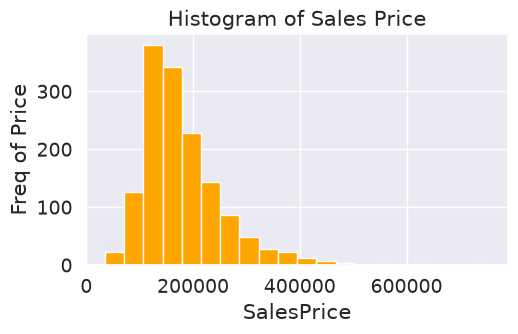

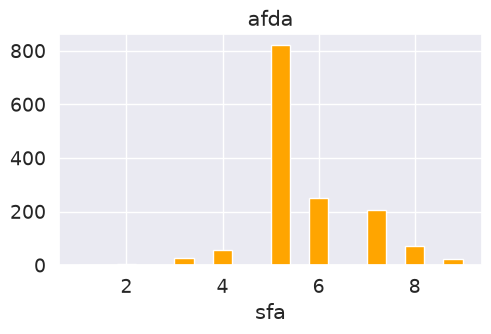

In [15]:
def hist_plot(x, title, xlabel, ylabel):
    plt.figure(figsize=(12,3))
    plt.subplot(121)
    plt.hist(x, bins= 20, color ='orange')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    
    
cols = df.drop('Id', axis= 1).columns.values
print(cols)
hist_plot(df.SalePrice, 'Histogram of Sales Price', 'SalesPrice', 'Freq of Price')
hist_plot(df.OverallCond, 'afda','sfa','')

In [16]:
df.loc[:, df.isnull().any()]  # cols with missing values.isna().sum()

,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,NaN,NaN,0.0,Gd,TA,No,Unf,Unf,SBrkr,TA,Attchd,1999.0,RFn,TA,TA,NaN,NaN,NaN
1456,85.0,NaN,Stone,119.0,Gd,TA,No,ALQ,Rec,SBrkr,TA,Attchd,1978.0,Unf,TA,TA,NaN,MnPrv,NaN
1457,66.0,NaN,NaN,0.0,TA,Gd,No,GLQ,Unf,SBrkr,Gd,Attchd,1941.0,RFn,TA,TA,NaN,GdPrv,Shed
1458,68.0,NaN,NaN,0.0,TA,TA,Mn,GLQ,Rec,FuseA,NaN,Attchd,1950.0,Unf,TA,TA,NaN,NaN,NaN


In [17]:
df[['YearBuilt']]//10

,YearBuilt
0,200
1,197
2,200
3,191
4,200
...,...
1455,199
1456,197
1457,194
1458,195
